# 🍜 Visual Question Answering — Món Ăn Việt Nam
## Hướng B: Multimodal Pretrained — PaliGemma

Notebook này thực hiện **so sánh B1 (Zero-shot) và B2 (Fine-tuned)** sử dụng model **PaliGemma-3B-mix-224** của Google.

| Thành phần | Chi tiết |
|---|---|
| **Model** | `google/paligemma-3b-mix-224` |
| **Quantization** | 4-bit NF4 (bitsandbytes) |
| **Fine-tune method** | LoRA (PEFT) — r=32, alpha=64 |
| **Ngôn ngữ** | Tiếng Việt trực tiếp (không dịch) |
| **Dataset** | `dung3008/vqa-food-vietnamese` |
| **Tập test** | 584 mẫu |

### Chiến lược xử lý tiếng Việt
PaliGemma được pretrain trên **WebLI** — dataset đa ngôn ngữ bao gồm tiếng Việt — nên model có khả năng hiểu và sinh văn bản tiếng Việt **trực tiếp mà không qua dịch máy**, tránh hoàn toàn lỗi garbage token gặp phải khi dùng BLIP-2.

### Pipeline
```
Ảnh + Câu hỏi (VI) → PaliGemma → Câu trả lời (VI)
```

##  1. Cài đặt thư viện

In [ ]:
!pip install -q -U transformers>=4.41 accelerate bitsandbytes peft \
             deep-translator rouge-score bert-score nltk datasets \
             'Pillow<11.0.0' nltk torchmetrics
!pip install -q nltk
import nltk
nltk.download('wordnet', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

True

##  2. Import thư viện & kiểm tra GPU

In [2]:
import torch, os, requests, re, time, numpy as np, shutil, random
from PIL import Image
from io import BytesIO
from datasets import load_dataset
from transformers import PaliGemmaProcessor, PaliGemmaForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel
from tqdm import tqdm
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer
from bert_score import score as bert_score_fn
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'DejaVu Sans'

print(f'GPU  : {torch.cuda.get_device_name(0)}')
print(f'VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

GPU  : Tesla T4
VRAM : 15.6 GB


##  3. Kết nối Google Drive & HuggingFace

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from huggingface_hub import login
login(token='YOUR_TOKEN_HERE')  

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##  4. Cấu hình đường dẫn

In [4]:
MODEL_ID  = 'google/paligemma-3b-mix-224'
DRIVE_DIR = '/content/drive/MyDrive/vqa_food/paligemma'
LORA_PATH = '/content/drive/MyDrive/vqa_food/paligemma'


os.makedirs(DRIVE_DIR, exist_ok=True)

##  5. Load Dataset

Dataset sử dụng: [`dung3008/vqa-food-vietnamese`](https://huggingface.co/datasets/dung3008/vqa-food-vietnamese)

| Split | Số mẫu |
|---|---|
| Train | 12,810 |
| Validation | 554 |
| Test | 584 |

Mỗi mẫu gồm: `image_path`, `question`, `answer`, `question_type` với 3 loại câu hỏi:

| Loại | Mô tả | Ví dụ |
|---|---|---|
| `recognition` | Nhận diện món ăn | "Trong ảnh là món gì?" |
| `attribute` | Thuộc tính món ăn | "Màu sắc chủ đạo là gì?" |
| `yes/no` | Câu hỏi có/không | "Có nước chấm không?" |

In [5]:
dataset   = load_dataset('dung3008/vqa-food-vietnamese')
test_data = dataset['test']
print(f'Test: {len(test_data)} samples')
print(f'Sample: {test_data[0]}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Test: 584 samples
Sample: {'question': 'trong ảnh là món ăn gì', 'answer': 'bánh bèo', 'question_type': 'recognition', 'answer_type': 'text', 'image_path': 'test/Banh_Beo/69.jpg', 'dish': 'Banh_Beo'}


##  6. Hàm load ảnh từ HuggingFace

In [6]:
HF_BASE_URL = 'https://huggingface.co/datasets/dung3008/vqa-food-vietnamese/resolve/main/images'
image_cache = {}

def load_image_from_hf(image_path: str) -> Image.Image:
    if image_path in image_cache:
        return image_cache[image_path]
    url = f'{HF_BASE_URL}/{image_path}'
    response = requests.get(url, timeout=15)
    if response.status_code != 200:
        raise ValueError(f'Cannot load: {url} ({response.status_code})')
    img = Image.open(BytesIO(response.content)).convert('RGB')
    image_cache[image_path] = img
    return img

##  7. Load Model PaliGemma (4-bit Quantization)

Model được load với **4-bit NF4 quantization** để tiết kiệm VRAM, cho phép chạy trên GPU T4 (15.6 GB).

| Tham số | Giá trị |
|---|---|
| `load_in_4bit` | True |
| `bnb_4bit_quant_type` | nf4 |
| `bnb_4bit_compute_dtype` | bfloat16 |
| `device_map` | cuda:0 |

In [7]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4',
    bnb_4bit_compute_dtype=torch.bfloat16,
)

print('Loading processor...')
processor = PaliGemmaProcessor.from_pretrained(MODEL_ID)

print('Loading base model...')
base_model = PaliGemmaForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map='cuda:0',
    torch_dtype=torch.bfloat16,
)
base_model.eval()
print(f'Base model loaded! VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')

Loading processor...
Loading base model...


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

Base model loaded! VRAM: 2.29 GB


##  8. Hàm Dự đoán

Cả B1 và B2 dùng chung pipeline sinh câu trả lời, chỉ khác ở model đầu vào:

| | B1 Zero-shot | B2 Fine-tuned |
|---|---|---|
| **Model** | Base PaliGemma | PaliGemma + LoRA |
| **Prompt** | `<image> Câu hỏi: ... Trả lời:` | `<image> Câu hỏi: ... Trả lời:` |
| **max_new_tokens** | 20 | 20 |
| **num_beams** | 3 | 3 |

In [8]:
def _generate(model, image, question_vi):
    prompt = f'<image> Câu hỏi: {question_vi} Trả lời:'
    inputs = processor(
        images=image,
        text=prompt,
        return_tensors='pt',
    ).to('cuda:0', torch.bfloat16)

    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=20,
            num_beams=3,
            repetition_penalty=2.0,
            no_repeat_ngram_size=2,
            early_stopping=True,
        )

    input_len = inputs['input_ids'].shape[1]
    answer = processor.decode(
        generated_ids[0][input_len:],
        skip_special_tokens=True
    ).strip()

    answer = answer.split('.')[0].strip()
    answer = re.sub(r'(\b\w+\b)(\s*\1)+', r'\1', answer).strip()
    answer = re.sub(r'(.+?)\1+', r'\1', answer).strip()

    # Chuẩn hóa yes/no
    if answer.strip().lower() in ['yes', 'yeah', 'yep']:
        answer = 'có'
    elif answer.strip().lower() in ['no', 'nope', 'not']:
        answer = 'không'

    return answer.strip()


def predict_b1(image, question_vi):
    return _generate(base_model, image, question_vi)

def predict_b2(image, question_vi):
    return _generate(peft_model_best, image, question_vi)

##  9. Định nghĩa các Metric Đánh giá

| Metric | Mô tả |
|---|---|
| **Exact Match** | Tỉ lệ câu trả lời khớp hoàn toàn với ground truth |
| **Soft Accuracy** | Độ tương đồng theo Jaccard (giao/hợp của tập từ) |
| **BLEU-1** | Độ chính xác unigram có smoothing |
| **ROUGE-L** | F1 dựa trên longest common subsequence |
| **METEOR** | Kết hợp precision, recall và stemming |
| **BERTScore F1** | Độ tương đồng ngữ nghĩa dùng multilingual BERT |

In [9]:
rouge  = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=False)
smooth = SmoothingFunction().method1

def exact_match(pred, gt):
    return float(pred.strip().lower() == gt.strip().lower())

def soft_accuracy(pred, gt):
    p = set(pred.strip().lower().split())
    g = set(gt.strip().lower().split())
    if not p or not g: return 0.0
    return len(p & g) / len(p | g)

def bleu1(pred, gt):
    ref = [gt.strip().lower().split()]
    hyp = pred.strip().lower().split()
    if not hyp: return 0.0
    return sentence_bleu(ref, hyp, weights=(1,0,0,0), smoothing_function=smooth)

def rouge_l(pred, gt):
    return rouge.score(gt, pred)['rougeL'].fmeasure

def meteor(pred, gt):
    return meteor_score([gt.strip().lower().split()], pred.strip().lower().split())

def compute_metrics(preds, gts, label=''):
    print(f'\nComputing metrics {label}...')
    em     = [exact_match(p, g)   for p, g in zip(preds, gts)]
    soft   = [soft_accuracy(p, g) for p, g in zip(preds, gts)]
    bleu   = [bleu1(p, g)         for p, g in zip(preds, gts)]
    rougel = [rouge_l(p, g)       for p, g in zip(preds, gts)]
    met    = [meteor(p, g)        for p, g in zip(preds, gts)]
    print('  Computing BERTScore...')
    _, _, F1 = bert_score_fn(
        preds, gts,
        lang='vi',
        model_type='bert-base-multilingual-cased',
        verbose=False,
        device='cuda' if torch.cuda.is_available() else 'cpu',
        batch_size=32,
    )
    return {
        'exact_match'  : round(np.mean(em)         * 100, 2),
        'soft_accuracy': round(np.mean(soft)        * 100, 2),
        'bleu1'        : round(np.mean(bleu)        * 100, 2),
        'rouge_l'      : round(np.mean(rougel)      * 100, 2),
        'meteor'       : round(np.mean(met)         * 100, 2),
        'bert_score_f1': round(np.mean(F1.tolist()) * 100, 2),
    }

##  10. Đánh giá B1 — Zero-shot

In [10]:
results_b1    = []
questions     = []
qtypes        = []
ground_truths = []
N_EVAL = len(test_data)
print(f'Chạy B1 zero-shot trên {N_EVAL} mẫu...\n')
start = time.time()

for i in tqdm(range(N_EVAL)):
    sample = test_data[i]
    questions.append(sample['question'])
    qtypes.append(sample['question_type'])
    ground_truths.append(sample['answer'])
    try:
        img  = load_image_from_hf(sample['image_path'])
        pred = predict_b1(img, sample['question'])
    except Exception as e:
        print(f'[WARN] {i}: {e}')
        pred = ''
    results_b1.append(pred)

print(f'Done! {(time.time()-start)/60:.1f} phút')
metrics_b1 = compute_metrics(results_b1, ground_truths, 'B1 Zero-shot')

print('\n' + '='*40)
print('KẾT QUẢ B1 — Zero-shot')
print('='*40)
for k, v in metrics_b1.items():
    print(f'  {k:<20}: {v:.2f}%')

Chạy B1 zero-shot trên 584 mẫu...



100%|██████████| 584/584 [24:26<00:00,  2.51s/it]


Done! 24.4 phút

Computing metrics B1 Zero-shot...
  Computing BERTScore...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



KẾT QUẢ B1 — Zero-shot
  exact_match         : 24.49%
  soft_accuracy       : 30.96%
  bleu1               : 29.76%
  rouge_l             : 39.57%
  meteor              : 18.21%
  bert_score_f1       : 81.39%


##  11. Load LoRA Checkpoint (B2)

Load LoRA weights đã được fine-tune từ Google Drive vào base model.

| Tham số LoRA | Giá trị |
|---|---|
| **r** | 32 |
| **lora_alpha** | 64 |
| **target_modules** | q_proj, v_proj, k_proj, o_proj |
| **Training data** | 5,000 mẫu |
| **Epochs** | 2 |

In [11]:
print(f'Loading LoRA từ {LORA_PATH}...')
peft_model_best = PeftModel.from_pretrained(base_model, LORA_PATH)
peft_model_best.eval()
print(f'LoRA loaded! VRAM: {torch.cuda.memory_allocated()/1e9:.2f} GB')

Loading LoRA từ /content/drive/MyDrive/vqa_food/paligemma...
LoRA loaded! VRAM: 2.33 GB


##  12. Đánh giá B2 — Fine-tuned

In [12]:
results_b2 = []

print(f'Chạy B2 fine-tuned trên {N_EVAL} mẫu...\n')
start = time.time()

for i in tqdm(range(N_EVAL)):
    sample = test_data[i]
    try:
        img  = load_image_from_hf(sample['image_path'])
        pred = predict_b2(img, sample['question'])
    except Exception as e:
        print(f'[WARN] {i}: {e}')
        pred = ''
    results_b2.append(pred)

print(f'Done! {(time.time()-start)/60:.1f} phút')
metrics_b2 = compute_metrics(results_b2, ground_truths, 'B2 Fine-tuned')

print('\n' + '='*40)
print('KẾT QUẢ B2 — Fine-tuned')
print('='*40)
for k, v in metrics_b2.items():
    print(f'  {k:<20}: {v:.2f}%')

Chạy B2 fine-tuned trên 584 mẫu...



100%|██████████| 584/584 [23:32<00:00,  2.42s/it]


Done! 23.5 phút

Computing metrics B2 Fine-tuned...
  Computing BERTScore...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-multilingual-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.



KẾT QUẢ B2 — Fine-tuned
  exact_match         : 51.88%
  soft_accuracy       : 59.01%
  bleu1               : 56.73%
  rouge_l             : 65.84%
  meteor              : 37.59%
  bert_score_f1       : 89.26%


##  14. Biểu đồ So sánh Metrics

Biểu đồ cột so sánh trực quan 6 metrics giữa B1 Zero-shot và B2 Fine-tuned.

In [13]:
print('\n' + '='*62)
print('SO SÁNH B1 (Zero-shot) VS B2 (Fine-tuned) — PaliGemma')
print('='*62)
print(f'{"Metric":<20} | {"B1 Zero-shot":>12} | {"B2 Fine-tuned":>13} | {"Delta":>8}')
print('-'*62)
for k in metrics_b2:
    b1  = metrics_b1.get(k, 0)
    b2  = metrics_b2[k]
    d   = b2 - b1
    arr = '↑' if d > 0 else ('↓' if d < 0 else '=')
    print(f'{k:<20} | {b1:>11.2f}% | {b2:>12.2f}% | {arr}{abs(d):.2f}%')

# Lưu CSV
df = pd.DataFrame({
    'Câu hỏi'             : questions,
    'Loại câu hỏi'        : qtypes,
    'Đáp án gốc (GT)'     : ground_truths,
    'Pred B1 (Zero-shot)' : results_b1,
    'Pred B2 (Fine-tuned)': results_b2,
})

df.to_csv('B1_vs_B2_paligemma.csv', index=False, encoding='utf-8-sig')
df.to_csv(f'{DRIVE_DIR}/B1_vs_B2_paligemma.csv', index=False, encoding='utf-8-sig')
print(f'\nĐã lưu: {DRIVE_DIR}/B1_vs_B2_paligemma.csv')
display(df.head(10))


SO SÁNH B1 (Zero-shot) VS B2 (Fine-tuned) — PaliGemma
Metric               | B1 Zero-shot | B2 Fine-tuned |    Delta
--------------------------------------------------------------
exact_match          |       24.49% |        51.88% | ↑27.39%
soft_accuracy        |       30.96% |        59.01% | ↑28.05%
bleu1                |       29.76% |        56.73% | ↑26.97%
rouge_l              |       39.57% |        65.84% | ↑26.27%
meteor               |       18.21% |        37.59% | ↑19.38%
bert_score_f1        |       81.39% |        89.26% | ↑7.87%

Đã lưu: /content/drive/MyDrive/vqa_food/paligemma/B1_vs_B2_paligemma.csv


,Câu hỏi,Loại câu hỏi,Đáp án gốc (GT),Pred B1 (Zero-shot),Pred B2 (Fine-tuned)
0,trong ảnh là món ăn gì,recognition,bánh bèo,Cận cảnh thức ăn,bánh bèo
1,món ăn có màu sắc chủ đạo là gì,attribute,màu sắc chủ đạo là màu trắng,Màu đỏ,trắng
2,món ăn này có đi kèm nước chấm không,yes/no,không,có,có
3,đây có phải là món bánh bèo không,yes/no,có,không,có
4,món ăn được đặt ở đâu,attribute,trong chén,trên bàn,trên bàn
5,món ăn có được bày trên bàn không,yes/no,có,có,có
6,màu sắc của topping trên món ăn là gì,attribute,màu vàng cam,Màu đỏ và màu vàng,vàng cam
7,trong ảnh là món gì,recognition,bánh bèo,cơm tấm,bánh bèo
8,món ăn này có nước chấm đi kèm không,yes/no,có,có,có
9,màu sắc chủ đạo của món ăn là màu gì,attribute,màu sắc chủ đạo là màu trắng,Màu đỏ,trắng


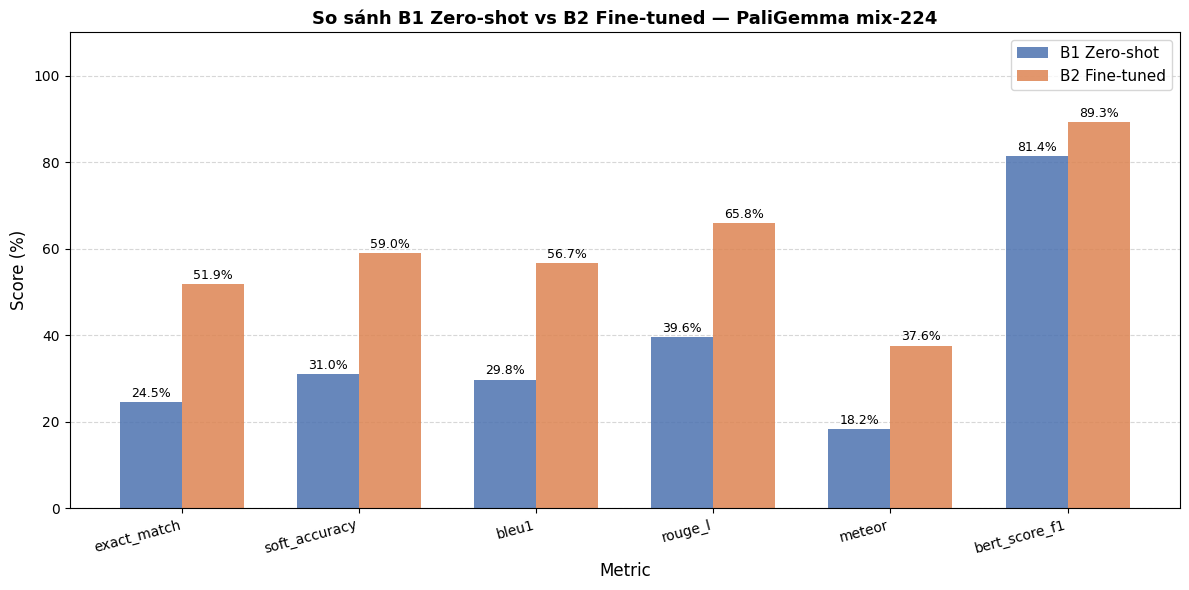

Đã lưu biểu đồ!


In [14]:
metrics_names = list(metrics_b1.keys())
b1_values     = [metrics_b1[k] for k in metrics_names]
b2_values     = [metrics_b2[k] for k in metrics_names]

x     = np.arange(len(metrics_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 6))

bars1 = ax.bar(x - width/2, b1_values, width, label='B1 Zero-shot',  color='#4C72B0', alpha=0.85)
bars2 = ax.bar(x + width/2, b2_values, width, label='B2 Fine-tuned', color='#DD8452', alpha=0.85)

# Thêm giá trị lên bar
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score (%)', fontsize=12)
ax.set_title('So sánh B1 Zero-shot vs B2 Fine-tuned — PaliGemma mix-224', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics_names, rotation=15, ha='right')
ax.legend(fontsize=11)
ax.set_ylim(0, 110)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('B1_vs_B2_metrics.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{DRIVE_DIR}/B1_vs_B2_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu biểu đồ!')

##  15. Loss Curve — Quá trình Fine-tune B2

Biểu đồ thể hiện sự thay đổi của **Train Loss** và **Validation Loss** qua các epoch trong quá trình fine-tune PaliGemma với LoRA.

| Epoch | Train Loss | Val Loss |
|---|---|---|
| 1 | 0.9644 | 0.7261 |
| 2 | 0.4727 | 0.7674 |

> **Nhận xét:** Val Loss tăng ở epoch 2 → early stopping kích hoạt, checkpoint tốt nhất là epoch 1.

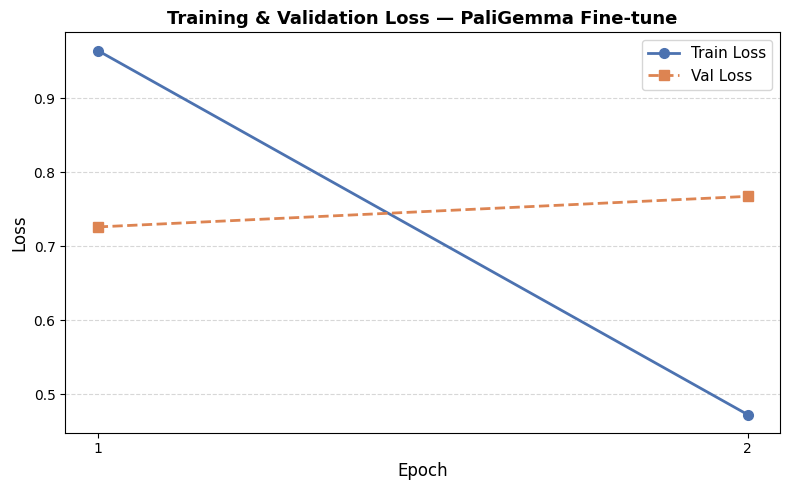

Đã lưu loss curve!


In [ ]:

train_losses = [0.9644, 0.4727]   
val_losses   = [0.7261, 0.7674]   

epochs = list(range(1, len(train_losses) + 1))

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(epochs, train_losses, 'o-', color='#4C72B0', linewidth=2, markersize=7, label='Train Loss')
ax.plot(epochs, val_losses,   's--', color='#DD8452', linewidth=2, markersize=7, label='Val Loss')

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Loss', fontsize=12)
ax.set_title('Training & Validation Loss — PaliGemma Fine-tune', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xticks(epochs)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150, bbox_inches='tight')
plt.savefig(f'{DRIVE_DIR}/loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print('Đã lưu loss curve!')